In [19]:
import sys, os
sys.path.append(os.path.abspath("../../"))

# Load shared utilities for attention-from-scratch analysis
from scripts.attention_from_scratch_utils import *

# Set reproducible seed
set_seed(42)

print("Environment ready.")
print("Device:", device)

Environment ready.
Device: mps


# 04 — Position-Wise Feed-Forward Network (FFN)

The Feed-Forward Network (FFN) is the part of a Transformer block that lets **each token process information on its own**, adding the nonlinear expressive power that attention alone cannot provide.

In this notebook, we walk through the FFN step-by-step using a simple, readable toy example (**8 → 16 → 8**) that mirrors how real models scale (e.g., **768 → 3072 → 768** in BERT or **12,288 → 49,152 → 12,288** in GPT-3).

---

## What This Notebook Covers (In Order)

### **1. The structure of the FFN**
- How a token embedding is transformed by two linear layers with a nonlinear activation in between  
- Why the FFN operates **independently** on each token  

### **2. Visual intuition**
- Node diagrams of the FFN  
- Tables showing intermediate values  
- Side-by-side comparisons of token representations before and after each stage  

### **3. Expansion → Activation → Projection**
- **Expansion (8 → 16):** creating a larger feature space  
- **GELU activation:** adding nonlinearity and shaping those features  
- **Projection (16 → 8):** compressing them back to the model dimension  

### **4. The tensors involved**
- Input token embeddings  
- Weight matrices $(W_1, W_2$)  
- Bias vectors $(b_1, b_2$)  
- How these interact mathematically in each step  

### **5. Activation functions in context**
- Why GELU is commonly used  
- How it compares to ReLU, SiLU/Swish, and gated activations (GEGLU, SwiGLU)  

### **6. Scaling to real models**
- How the same FFN pattern appears in GPT-2, BERT, GPT-3, LLaMA, and others  
- Why FFNs remain efficient even at large scales  

---

By the end, you’ll have a clear, practical understanding of **what the FFN does**, **why it exists**, and **how it transforms each token’s representation** inside a Transformer block.

# Feed-Forward Network (FFN): What It Is and Why It Matters

The **Feed-Forward Network (FFN)** is the part of a Transformer layer that lets each token **“think” for itself** after it has gathered information from other tokens through attention.

Even though attention gets most of the spotlight, the FFN is *just as important* — without it, Transformers wouldn’t be powerful.

---

## Plain-English Explanation

After attention finishes, every token has learned something from the other tokens.  
But these “raw thoughts” are still messy. They need to be processed, refined, and turned into something meaningful.

That processing step is done by the FFN.

The FFN is a tiny 2-layer neural network that is applied **independently to each token**.  
It takes the updated embedding for a token and transforms it into a more useful representation.

---

# Analogy: Attention Is the Meeting, FFN Is the Desk Work

Imagine each token is a worker in a company.

### **Attention = the team meeting**  
All the workers get together and share information:

- Who is important?  
- Who relates to who?  
- What context matters?

After the meeting, everyone knows what’s going on.

But… knowing is not enough.

### **FFN = each worker back at their desk**  
After the meeting, every worker goes to their own desk and thinks:

> “Given everything I learned, what should *I* do with it?”

They process the information, take notes, reorganize ideas, and refine their own understanding.

Each worker uses the **same office tools** (same FFN weights),  
but they produce different results based on what they heard.

This step is essential — it turns information into action.

---

## What the FFN Actually Does

The FFN performs three steps for **each token separately**:

### **1. Expand the token’s vector**  
The token’s embedding (e.g., 512 dims) is projected to a much larger hidden size (e.g., 2048 dims).  
This gives the model **more room** to transform the information.

### **2. Apply a nonlinearity (ReLU or GELU)**  
This is where the FFN gets expressive power.  
Without this, the whole Transformer would be mostly linear and far less capable.

### **3. Project back down**  
The high-dimensional vector is compressed back to the original embedding size.  
This returns a refined token representation.

---

## Why This Helps So Much

The FFN adds capabilities that attention *cannot* provide alone:

### **✔ Nonlinearity**  
Attention is mostly linear. Without FFN, stacking layers wouldn’t increase expressive power.

### **✔ Feature creation**  
The FFN can create new abstract features inside each token.

### **✔ Local processing**  
Each token gets to compute its own interpretation of the context it received.

### **✔ Depth**  
In every Transformer layer:

Attention → FFN → Attention → FFN → …

This alternating pattern builds richer and richer representations.

---

## Putting It All Together

Here’s the full flow inside **one Transformer layer**:

1. **Token + Positional Embeddings**  
   Each token becomes a numeric vector.

2. **Attention**  
   Tokens talk to each other and share information.

3. **FFN**  
   Each token processes that information individually using a tiny neural network.

4. **Add & Norm**  
   Stabilizes training and keeps gradients healthy.

---

## In One Sentence

**The FFN takes the information each token learned from attention and transforms it into a richer, more meaningful representation — giving each token its own private “thinking step.”**

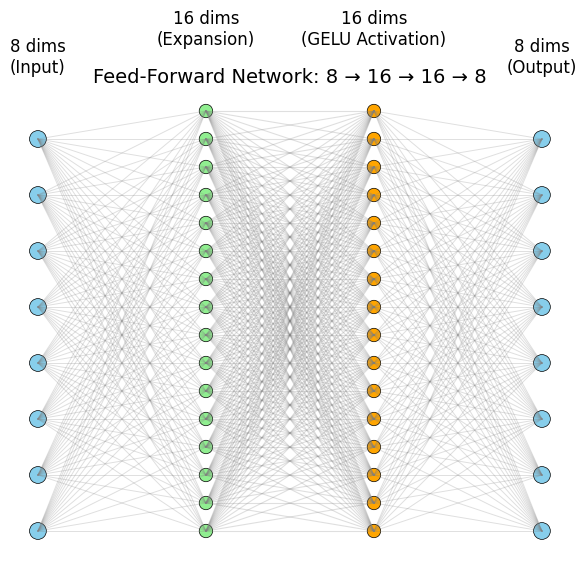

In [59]:
import matplotlib.pyplot as plt

# FFN node diagram: 8 → 16 → 16 → 8 (Expansion → GELU → Projection)

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_aspect('equal')
ax.axis('off')

# Layer x-positions
x_in, x_expand, x_gelu, x_out = 0, 3, 6, 9

# Layer y-positions
layer_in_y      = [i for i in range(8)]          # input 8 dims
layer_expand_y  = [i * 0.5 for i in range(16)]   # expanded 16 dims
layer_gelu_y    = [i * 0.5 for i in range(16)]   # activated 16 dims
layer_out_y     = [i for i in range(8)]          # output 8 dims

# Helper to add circular nodes
def add_nodes(x, ys, radius=0.15, color='skyblue'):
    for y in ys:
        circle = plt.Circle((x, y), radius, color=color, ec='black', lw=0.5)
        ax.add_artist(circle)

# Draw nodes
add_nodes(x_in,     layer_in_y,     radius=0.15, color='skyblue')     # input
add_nodes(x_expand, layer_expand_y, radius=0.12, color='lightgreen')  # expansion
add_nodes(x_gelu,   layer_gelu_y,   radius=0.12, color='orange')      # GELU
add_nodes(x_out,    layer_out_y,    radius=0.15, color='skyblue')     # output

# Draw edges: input → expansion
for y1 in layer_in_y:
    for y2 in layer_expand_y:
        ax.plot([x_in, x_expand], [y1, y2], color='gray', alpha=0.25, linewidth=0.7)

# Edges: expansion → GELU
for y1 in layer_expand_y:
    for y2 in layer_gelu_y:
        ax.plot([x_expand, x_gelu], [y1, y2], color='gray', alpha=0.25, linewidth=0.8)

# Edges: GELU → projection
for y1 in layer_gelu_y:
    for y2 in layer_out_y:
        ax.plot([x_gelu, x_out], [y1, y2], color='gray', alpha=0.25, linewidth=0.7)

# Labels above layers
ax.text(x_in,     max(layer_in_y) + 1.2,     "8 dims\n(Input)", ha='center', fontsize=12)
ax.text(x_expand, max(layer_expand_y) + 1.2, "16 dims\n(Expansion)", ha='center', fontsize=12)
ax.text(x_gelu,   max(layer_gelu_y) + 1.2,   "16 dims\n(GELU Activation)", ha='center', fontsize=12)
ax.text(x_out,    max(layer_out_y) + 1.2,    "8 dims\n(Output)", ha='center', fontsize=12)

ax.set_title("Feed-Forward Network: 8 → 16 → 16 → 8", fontsize=14)
plt.show()

# Mini Transformer Walkthrough (Tiny 8-Dimensional Example)

In this section, we’ll build a **tiny end-to-end Transformer layer example**, using:

- `8 tokens`
- `d_model = 8`
- `num_heads = 2`
- `head_dim = 4`

Instead of re-explaining the full mechanics of attention (covered already in Notebooks 01–03), we will **pretend all the earlier steps have already been performed**, and simply *create a small toy example* that represents the state of the model **right before the Feed-Forward Network (FFN)**.

This lets us focus on the part we care about in Notebook 04:  
**What does the FFN do to token embeddings?**

---

# What Steps Are “Pre-computed” in This Toy Setup?

To keep the demonstration simple, we assume the following steps have already occurred:

### ✔ 1. Token + Positional Embeddings  
Each token has been mapped to an 8-dimensional vector and position information has been added.

### ✔ 2. Multi-Head Attention  
Q, K, and V have already been computed, attention scores calculated, softmax applied, heads processed, and outputs merged.

### ✔ 3. Output Projection  
The outputs of the attention heads have been concatenated and passed through the final linear projection.

---

# Why Do It This Way?

Because this notebook focuses on the **Feed-Forward Network (FFN)**.  
To understand the FFN clearly, we want to:

- Start from attention outputs that *already contain contextual information*  
- Feed those vectors into the FFN  
- Observe how the FFN transforms them  
- Compare *before vs after*  

This avoids repeating previous notebooks and lets us focus entirely on the FFN transformation.

---

# What We Will Actually Build

We will:

1. Create a tiny set of **8 token embeddings** (8-dim vectors) that *represent the output of attention*.  
2. Feed them into a **tiny FFN**  
   - Expand: `8 → 16`  
   - GELU activation  
   - Project back: `16 → 8`  
3. Print the numbers at each step  
4. Visually compare *before vs after* embeddings  

This gives a crystal-clear intuition for what FFNs do inside a Transformer layer, using numbers small enough to read.

---

## Create 8 Toy Token Embeddings (After Positional Encoding + Multi-Head Attention)

In this section, we create a tiny, easy-to-read set of **8 token embeddings**, each with **8 dimensions**.

These are meant to **represent what the model looks like right after multi-head attention**, meaning:

- Token embeddings have already been created  
- Positional encodings have already been added  
- Tokens have already been processed through Q/K/V  
- Attention scores and softmax have already been applied  
- Two attention heads have been merged back together  
- The output projection has already been applied  

We now have **8 token vectors**, each containing contextual information the FFN will transform.

Below is the code that generates these toy embeddings.

In [33]:
import torch
import pandas as pd
from IPython.display import display, HTML

# Use simple, readable values instead of noisy Gaussian samples
# We'll generate values in the range [-1.0, 1.0] and round to 1 decimal place

num_tokens = 8
d_model = 8

# Create simple toy embeddings
torch.manual_seed(42)
attention_output = torch.rand(num_tokens, d_model) * 2 - 1    # values in [-1, 1]
attention_output = attention_output.round(decimals=1)         # clean, simple decimals

# Token labels
tokens = [f"Token{i}" for i in range(num_tokens)]

# Build DataFrame
df_embeddings = pd.DataFrame(
    attention_output.numpy(),
    columns=[f"dim_{i}" for i in range(d_model)]
)
df_embeddings.insert(0, "token", tokens)

display(HTML("<h3>Post-Attention Token Embeddings (Simplified Toy Example)</h3>"))
display(df_embeddings)

,token,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,Token0,0.8,0.8,-0.2,0.9,-0.2,0.2,-0.5,0.6
1,Token1,0.9,-0.7,0.9,0.2,0.7,0.1,0.5,-0.1
2,Token2,0.8,0.1,-0.5,0.3,-0.5,-0.1,-0.4,0.7
3,Token3,-0.8,-0.5,-0.3,-0.6,0.1,-1.0,0.9,-0.8
4,Token4,0.8,0.2,-0.3,0.6,0.2,0.8,0.1,-0.3
5,Token5,0.3,-0.3,0.4,0.9,0.6,-0.4,0.6,0.2
6,Token6,0.5,-0.6,-1.0,-0.4,-0.8,0.8,0.3,0.4
7,Token7,0.3,-0.0,0.8,-0.7,0.1,-0.7,0.3,-0.3


### How Expansion and GELU Create New Features (Simple Analogy)

When a token goes into the Feed-Forward Network (FFN), two important steps happen:

---

## 1️Expansion (8 → 16): *“Give the model more space to think”*

Think of the token’s 8-dimensional embedding like **8 colored pencils**.

Expansion mixes all 8 pencils together in different proportions and creates **16 new colors** you didn’t have before.

These new 16 values are:

- weighted mixes of all original inputs  
- new directions in feature space  
- still *linear* combinations (straight lines, no curves)

This step gives the model a **bigger desk** and more room to form new ideas.

---

## 2️GELU Activation: *“Shape those ideas into something meaningful”*

Now that the model has 16 new colors, GELU decides:

- which colors to brighten  
- which ones to dim  
- which ones to keep only if they’re strong  
- which ones to gently suppress  

GELU adds **nonlinearity**, meaning it can detect patterns like:

- “activate only when this feature is big”  
- “stop activating when this combination is small”  
- “softly gate or emphasize certain dimensions”

This is where the model starts forming **complex, abstract features** that simple linear mixing cannot capture.

---

## Together

- **Expansion** creates new space  
- **GELU** sculpts that space  

This pairing lets the Transformer learn patterns and relationships  
that humans would never explicitly define — including subtle similarities  
between words like *“fish”* and *“letterbox”* in ways that only emerge  
through these richer, learned feature dimensions.

## Step 1 — Expansion (8 → 16): What Actually Happens in the FFN

The first step of the Feed-Forward Network takes each token’s embedding and **expands it** from  
**8 dimensions → 16 dimensions**.

This is done using a **linear transformation**:

$$
h = xW_1 + b_1
$$

Where:

- $x$ is the token’s 8-dimensional vector  
- $W_1$ is a learned weight matrix of shape **(8 \times 16)**  
- $b_1$ is a learned bias vector of shape **(16)**  
- $h$ becomes the new **16-dimensional** hidden representation

---

### Why expand the vector?

By increasing the dimensionality, the model:

- creates more room to form **new abstract features**  
- allows richer and more expressive transformations  
- escapes the limits of purely linear attention  
- gives each token a “bigger thinking space”  
- prepares the representation for nonlinear activation (GELU)

Think of this as stretching the token into a **wider workspace**.

---

### What does the math look like?

For each token embedding:

1. Take the token’s 8 input values  
2. Multiply them with an $8 \times 16$ matrix  
3. Add a 16-dimensional bias  
4. The result is **16 new numbers**

If the token embedding is:

$$
x = [x_0, x_1, \dots, x_7]
$$

Then each of the 16 expanded dimensions is:

$$
h_j = (x_0 W_{0j}) + (x_1 W_{1j}) + \dots + (x_7 W_{7j}) + b_{1j}
$$

This is repeated for all 16 output dimensions, giving:

$$
h = [h_0, h_1, \dots, h_{15}]
$$

---

## Are There Other Tensors Involved in This Step?

Yes — the FFN expansion relies on **three key tensors**, all learned during training:

### **1. The input token embeddings**
These come from the previous part of the Transformer (attention).  
Shape:  
**(num_tokens × d_model)**  
In our toy example: **(8 × 8)**

These embeddings already contain:

- token meaning  
- positional information  
- contextual information from attention

---

### **2. The weight matrix $W_1$**
This is the core of the expansion step.  
Shape: **(d_model × hidden_dim)**  
Real models often use:
- **512 → 2048** (BERT-base)
- **768 → 3072** (GPT-2 small)
- **4096 → 16384** (GPT-3 scale models)

This matrix defines **how the model mixes the 8 input dims into 16 new dims.**

---

### **3. The bias vector $b_1$**
A 16-dimensional learned bias.  
Shape: **(hidden_dim)**  
It shifts the output so that the model isn’t forced to pass through the origin.

---

## How Are These Used in Real Transformer Models?

In practice:

- The **expansion matrix $W_1$** learns thousands of tiny “feature detectors.”
- Each expanded dimension becomes a **meaningful signal** the model can use later.
- The **bias $b_1$** fine-tunes the shape of those signals.
- This happens **for every token**, in **every Transformer layer**, often billions of times during pretraining.

This step is essential because:

- Attention mixes information *between tokens*  
- The FFN expansion lets each token *individually* build new internal features  
- The nonlinear activation (GELU) then shapes these features  
- The final projection (16 → 8) condenses them back into the model dimension

In other words:

> **Expansion creates the space for new features.**  
> **GELU sculpts those features.**  
> **Projection compresses them back into the token embedding.**

---

## Summary

- The expansion step introduces new learned features.
- It uses three tensors: input embeddings, $W_1$, and $b_1$.
- Real models massively scale this (e.g., 4096 → 16384).
- This step is critical for giving Transformers nonlinear expressive power.

In the next step, we will apply **GELU** to the expanded tensor to create richer nonlinear features.

In [27]:
import torch
import pandas as pd
from IPython.display import display, HTML

# -------------------------------------------------
# 1) Input: Simple toy post-attention embeddings
# -------------------------------------------------
torch.manual_seed(42)

num_tokens = 8
d_model = 8
hidden_dim = 16  # FFN hidden size

# Generate readable values in [-1, 1]
attention_output = torch.rand(num_tokens, d_model) * 2 - 1
attention_output = attention_output.round(decimals=1)

tokens = [f"Token{i}" for i in range(num_tokens)]

df_in = pd.DataFrame(
    attention_output.numpy(),
    columns=[f"dim_{i}" for i in range(d_model)]
)
df_in.insert(0, "token", tokens)

display(HTML("<h3>Input: Post-Attention Token Embeddings (8 dims — Simple Values)</h3>"))
display(df_in)

# -------------------------------------------------
# 2) FFN Step 1 — Linear Expansion (8 → 16)
# -------------------------------------------------

# Random small FFN parameters (kept the same)
W1 = torch.randn(d_model, hidden_dim) * 0.2
b1 = torch.randn(hidden_dim) * 0.2

# Apply linear expansion
h1 = attention_output @ W1 + b1
h1_rounded = h1.round(decimals=3)

df_h1 = pd.DataFrame(
    h1_rounded.numpy(),
    columns=[f"h1_{i}" for i in range(hidden_dim)]
)
df_h1.insert(0, "token", tokens)

display(HTML("<h3>After FFN Expansion Layer (8 → 16)</h3>"))
display(df_h1)

,token,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,Token0,0.8,0.8,-0.2,0.9,-0.2,0.2,-0.5,0.6
1,Token1,0.9,-0.7,0.9,0.2,0.7,0.1,0.5,-0.1
2,Token2,0.8,0.1,-0.5,0.3,-0.5,-0.1,-0.4,0.7
3,Token3,-0.8,-0.5,-0.3,-0.6,0.1,-1.0,0.9,-0.8
4,Token4,0.8,0.2,-0.3,0.6,0.2,0.8,0.1,-0.3
5,Token5,0.3,-0.3,0.4,0.9,0.6,-0.4,0.6,0.2
6,Token6,0.5,-0.6,-1.0,-0.4,-0.8,0.8,0.3,0.4
7,Token7,0.3,-0.0,0.8,-0.7,0.1,-0.7,0.3,-0.3


,token,h1_0,h1_1,h1_2,h1_3,h1_4,h1_5,h1_6,h1_7,h1_8,h1_9,h1_10,h1_11,h1_12,h1_13,h1_14,h1_15
0,Token0,0.504,-0.150,0.217,0.120,-0.113,-0.075,-0.212,0.624,0.268,0.165,-0.562,0.146,0.233,-0.212,0.238,0.025
1,Token1,0.164,0.282,0.747,-0.027,-0.070,0.255,0.040,0.417,-0.047,0.917,0.036,0.033,0.196,0.680,-0.351,0.145
2,Token2,0.733,-0.231,0.403,0.113,-0.335,-0.326,-0.404,0.508,0.045,0.096,-0.332,-0.189,0.488,-0.246,0.107,-0.106
3,Token3,0.333,-0.454,-0.223,-0.493,-0.326,0.203,0.506,-0.098,-0.181,0.603,0.549,-0.731,0.016,0.611,0.647,0.234
4,Token4,0.444,0.089,0.625,0.241,-0.010,0.150,-0.157,0.617,0.218,0.743,-0.151,0.274,-0.328,0.065,-0.197,0.212
5,Token5,0.061,-0.015,0.030,-0.214,-0.105,0.153,0.092,0.312,-0.071,0.613,-0.083,-0.051,0.402,0.614,0.313,0.351
6,Token6,0.541,-0.133,0.892,0.387,-0.443,-0.601,-0.631,0.257,-0.228,0.476,0.074,-0.191,-0.187,-0.264,-0.155,0.193
7,Token7,0.303,-0.148,0.329,-0.332,-0.181,0.254,0.452,0.164,-0.024,0.577,0.167,-0.450,0.146,0.489,0.186,-0.081


## Do Input Dimensions Map to Specific Expanded Dimensions?

**Short answer:**  
**No.** There is *no* direct or fixed mapping between an input dimension (e.g., `token 0, dim_0`) and any specific expanded dimension in the FFN (e.g., `h1_0`, `h1_1`, …, `h1_15`).

---

## Why Not?

The FFN expansion layer is a **fully connected linear transformation**:

$$
h = xW_1 + b_1
$$

- Each token embedding \(x\) has **8 dimensions**  
- The matrix \(W_1\) has shape **8 × 16**  
- Each expanded output dimension is a **weighted mixture of all 8 input dimensions**

So an expanded dimension is computed as:

$$
h_j = \sum_{i=0}^{7} x_i \cdot W_{ij} + b_j
$$

This means:

### ✔ Every input dimension influences **every** expanded dimension  
### ✔ There is **no 1-to-1 mapping** between input and output dimensions  
### ✔ Expanded dims are **learned combinations**, not copies

---

## Intuition

Think of each expanded dimension as a new “feature detector” built from **all** 8 original values.

- `expanded_dim_3` might detect something like “syntactic direction”
- `expanded_dim_9` might detect something like “semantic intensity”
- `expanded_dim_12` might detect a mixture of both

None of these features correspond directly to a single input dimension.

---

## Key Takeaways

- **No direct mapping:** Input dim 0 does *not* map to any specific expanded dim.  
- **Fully connected:** Each expanded dim is influenced by **all** input dims.  
- **Learned mixing:** The model learns how to mix input dims into richer features.  
- **This mixing power is what gives FFNs their expressive strength.**

In short:

### **Expanded dimensions are not copies — they are new, learned features created from all input dimensions.**

## Step 2 - GELU Activation — Giving the Model “Curved” Thinking

After we expand each token from **8 → 16** dimensions, the next step in the FFN is to apply the **GELU activation function**.

This is the moment where the model stops being purely linear and begins discovering **richer, more expressive nonlinear features**.

---

# What GELU Does (In Simple Terms)

Think of each of the 16 expanded values like the brightness of a light bulb.

GELU decides:

- which bulbs to **brighten**  
- which bulbs to **dim**  
- which bulbs to **ignore**  
- which bulbs to **let through softly**  

Unlike ReLU (which is a *hard* on/off switch), GELU acts like a **soft, intelligent dimmer switch**.  
It lets a neuron activate **only when it’s confident**, but not abruptly.

This subtle softness is one of the reasons GELU works so well in language models.

---

# The GELU Formula (Made Easy)

The formal definition is:

$$
\text{GELU}(x) = x \cdot \Phi(x)
$$

Where $( \Phi(x) $) is the cumulative normal distribution.

This looks complicated, but here’s the intuition:

- **Big positive values → almost unchanged**  
- **Small positive values → softened**  
- **Negative values → pushed gently toward zero**  

GELU creates a **curved** response:

big positive → keep it
small positive → soften it
negative      → suppress it

This allows the model to form patterns and relationships that **linear layers could never capture**.

---

# Why We Need GELU

The expansion layer (8 → 16) gives the model **more space** to build internal features.

But the model still needs a way to:

- favor some features  
- suppress others  
- create nonlinear interactions  
- detect thresholds or combinations  
- form abstract concepts  

That’s what GELU provides.

Without GELU:

- the FFN would be entirely linear  
- stacking more layers would not add expressive power  
- the model couldn’t learn many of the patterns language requires  

With GELU:

- the FFN can express **complex, curved decision boundaries**  
- tokens gain **richer internal representations**  
- the model can learn **subtle semantic distinctions**  

---

# Do All Models Use GELU?

**No.**  
Different Transformer variants use different activation functions:

- **ReLU** — used in the original 2017 Transformer  
- **GELU** — used in BERT, GPT-2, GPT-3  
- **SwiGLU / GEGLU** — used in newer models like PaLM, LLaMA, likely GPT-4  
- **SiLU / Swish** — used in some vision transformers  

So GELU is **popular**, but not universal.

## Activation Function Comparison Table

| Activation | Pros | Cons | Used In |
|------------|------|------|---------|
| **ReLU**<br>(Rectified Linear Unit) | • Simple and fast<br>• Very efficient on hardware<br>• Works well in deep models<br>• Easy to optimize | • Hard “on/off” boundary<br>• Zeroes out negatives completely<br>• Can "die" if neurons never activate<br>• Less smooth → weaker gradient flow | Original 2017 Transformer (Vaswani et al.) |
| **GELU**<br>(Gaussian Error Linear Unit) | • Smooth and probabilistic<br>• Better gradient flow than ReLU<br>• Allows small negative values → more expressive<br>• Empirically improves language models | • Slightly slower than ReLU<br>• Harder to implement by hand | BERT, GPT-2, GPT-3, T5 |
| **SiLU / Swish**<br>(x·sigmoid(x)) | • Smooth nonlinearity<br>• Strong empirical performance<br>• Keeps small negative values<br>• Often similar or slightly better than GELU | • More expensive to compute than ReLU<br>• Slightly less tested than GELU in LLMs | Some Vision Transformers, smaller LMs |
| **GLU family**<br>(GEGLU, SwiGLU, ReGLU) | • Introduces **gating**, improving expressiveness<br>• State-of-the-art in modern LLMs<br>• Better training stability<br>• Often yields strong perplexity gains | • Requires **doubling the hidden size** → more compute<br>• More parameters<br>• More complex implementation | PaLM, LLaMA-2/3, Falcon, Mistral |
| **Tanh** | • Smooth and bounded<br>• Historically used in RNNs | • Saturates → vanishing gradients<br>• Not expressive enough for LLMs<br>• Slower than ReLU/GELU | Mostly obsolete |
| **Sigmoid** | • Outputs probability-like values<br>• Smooth | • Strong saturation<br>• Very small gradients<br>• Rarely used outside gating (LSTMs/attention) | Not used as FFN activation |

---

## Key Takeaways

- **ReLU** → fast, simple, but harsh and less expressive  
- **GELU** → smooth, expressive, better for language modeling  
- **GLU family** → gated activations; *best performance* in modern LLMs  
- **SiLU/Swish** → similar to GELU but less widely used  
- **Tanh / Sigmoid** → outdated for Transformer FFNs

---

## Which One Should You Use?

For educational builds:  
➡️ **GELU** (matches most real Transformers)

For state-of-the-art research or replication:  
➡️ **GEGLU** or **SwiGLU** (used in LLaMA, PaLM, etc.)

For speed-critical or tiny models:  
➡️ **ReLU**

---

# For This Notebook

For clarity and simplicity,  
**we will use GELU**, because it is the activation function used in most modern language models  
and gives a smooth, intuitive demonstration of nonlinearity.

---

# In One Sentence

**The expansion step gives the model more room; GELU shapes that room into meaningful, nonlinear features.**

In [28]:
import torch
import pandas as pd
from IPython.display import display, HTML

# -------------------------------------------------
# GELU Function (PyTorch-style implementation)
# -------------------------------------------------
def gelu(x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0/3.1415926535)) * (x + 0.044715 * x**3)))

# -------------------------------------------------
# Apply GELU to the expanded 16-dimensional vectors
# -------------------------------------------------

h1_gelu = gelu(h1)                      # shape: (8 tokens, 16 dims)
h1_gelu_rounded = h1_gelu.round(decimals=3)

df_h1_gelu = pd.DataFrame(
    h1_gelu_rounded.numpy(),
    columns=[f"h1_gelu_{i}" for i in range(hidden_dim)]
)
df_h1_gelu.insert(0, "token", tokens)

display(HTML("<h3>After GELU Activation (Still 16 dims)</h3>"))
display(df_h1_gelu)

,token,h1_gelu_0,h1_gelu_1,h1_gelu_2,h1_gelu_3,h1_gelu_4,h1_gelu_5,h1_gelu_6,h1_gelu_7,h1_gelu_8,h1_gelu_9,h1_gelu_10,h1_gelu_11,h1_gelu_12,h1_gelu_13,h1_gelu_14,h1_gelu_15
0,Token0,0.349,-0.066,0.127,0.066,-0.051,-0.035,-0.088,0.458,0.162,0.093,-0.161,0.082,0.138,-0.088,0.141,0.013
1,Token1,0.092,0.173,0.577,-0.013,-0.033,0.153,0.021,0.276,-0.023,0.752,0.019,0.017,0.113,0.511,-0.127,0.081
2,Token2,0.563,-0.094,0.264,0.062,-0.123,-0.121,-0.139,0.352,0.023,0.052,-0.123,-0.080,0.335,-0.099,0.058,-0.049
3,Token3,0.210,-0.148,-0.092,-0.153,-0.121,0.118,0.351,-0.045,-0.078,0.438,0.389,-0.170,0.008,0.446,0.479,0.139
4,Token4,0.298,0.048,0.459,0.143,-0.005,0.084,-0.069,0.451,0.128,0.573,-0.066,0.167,-0.122,0.034,-0.083,0.124
5,Token5,0.032,-0.007,0.015,-0.089,-0.048,0.086,0.049,0.194,-0.033,0.448,-0.039,-0.025,0.264,0.448,0.195,0.223
6,Token6,0.382,-0.059,0.726,0.252,-0.146,-0.165,-0.167,0.155,-0.093,0.325,0.039,-0.081,-0.080,-0.105,-0.068,0.111
7,Token7,0.187,-0.065,0.207,-0.123,-0.077,0.153,0.305,0.093,-0.012,0.414,0.095,-0.147,0.082,0.336,0.107,-0.038


## Step 3 — Linear Projection (16 → 8)

After expanding each token from **8 → 16** dimensions and applying the **GELU** nonlinearity,  
the final step of the Feed-Forward Network (FFN) is to **project the vector back down** to the original model dimension.

This step ensures the FFN’s output has the **same dimensionality as the input** so it can be added back through the **residual connection**.

---

## The Mathematical Operation

The projection uses another learned linear transformation:

$$
\text{FFN}(x) = \text{GELU}(xW_1 + b_1)\, W_2 + b_2
$$

Where:

- \(W_2\) is a weight matrix of shape **(16 × 8)**  
- \(b_2\) is a bias vector of shape **(8)**  
- The output once again has shape **(8)** (the model dimension)

For each token:

$$
\text{output}_i = \sum_{k=0}^{15} h_{\text{gelu},k} \cdot W_{2,k i} + b_{2,i}
$$

This means each of the **8 final dimensions** is a weighted mixture of all **16 GELU-activated features**.

---

## Why We Project Back Down?

### ✔ To match the model dimension (d_model)
All Transformer sublayers expect vectors of the same size (in this example, 8).  
Attention outputs, embedding sizes, and residual connections all assume **d_model**.

### ✔ To complete the FFN bottleneck
The FFN works like:

1. **Expand** → more space to create new features  
2. **Nonlinearity** → new expressive transformations  
3. **Compress** → return to the original dimension, but now enriched  

This pattern is known as a **bottleneck MLP**, and it is used in nearly every Transformer architecture.

### ✔ To produce transformed features without changing vector size
The FFN doesn’t add new dimensions to the model.  
Instead, it **refines** the token representation and returns it to the main flow.

---

## Intuition

- The first layer (8 → 16) lets the model build **richer internal features**.  
- GELU shapes those features in a **nonlinear** way.  
- The second layer (16 → 8) **compresses that knowledge back** into the original embedding space.

So the token returns to the main Transformer pipeline with:

- more structure  
- more abstraction  
- more expressive meaning  

Even though the dimensionality is the same as before.

---

## Summary

The projection step:

- reduces the FFN’s expanded representation back to **d_model**  
- ensures compatibility with attention and residual connections  
- finalizes the FFN transformation  
- produces the refined token embedding used in the next Transformer sublayer

In short:

**Expand → Activate → Compress**  
is the core pattern that gives the FFN its power inside the Transformer.

In [29]:
# -------------------------------------------------
# 3) FFN Step 2 — Linear Projection (16 → 8)
# -------------------------------------------------

# Small random projection weights
W2 = torch.randn(hidden_dim, d_model) * 0.2   # 16 × 8
b2 = torch.randn(d_model) * 0.2               # 8 dims

# Apply projection
ffn_output = h1_gelu @ W2 + b2                # shape: (8 tokens, 8 dims)
ffn_output_rounded = ffn_output.round(decimals=3)

df_ffn_out = pd.DataFrame(
    ffn_output_rounded.numpy(),
    columns=[f"ffn_dim_{i}" for i in range(d_model)]
)
df_ffn_out.insert(0, "token", tokens)

display(HTML("<h3>Final FFN Output (Back to 8 dims)</h3>"))
display(df_ffn_out)

,token,ffn_dim_0,ffn_dim_1,ffn_dim_2,ffn_dim_3,ffn_dim_4,ffn_dim_5,ffn_dim_6,ffn_dim_7
0,Token0,-0.299,0.014,-0.238,-0.523,0.238,-0.295,-0.208,-0.073
1,Token1,0.029,0.262,-0.221,-0.463,0.066,-0.169,0.046,0.197
2,Token2,-0.325,-0.054,-0.182,-0.620,0.223,-0.244,-0.355,-0.236
3,Token3,0.087,-0.233,-0.224,-0.795,-0.029,-0.186,-0.074,-0.198
4,Token4,-0.131,0.334,-0.326,-0.390,0.184,-0.251,0.018,0.198
5,Token5,0.015,-0.055,-0.162,-0.586,0.127,-0.174,-0.135,-0.091
6,Token6,-0.146,0.277,-0.334,-0.596,0.104,-0.297,-0.099,0.149
7,Token7,-0.070,-0.003,-0.223,-0.642,-0.025,-0.209,-0.054,-0.030


# Recap: The Entire Feed-Forward Network (FFN) Process

In this notebook, we walked through **every step** of the Feed-Forward Network inside a Transformer block — using a **small toy example** with  
**8 → 16 → 8 dimensions** to keep everything easy to see.

In real Transformer models, these dimensions are **much larger** (e.g., 768 → 3072 → 768),  
but the mathematical structure is **identical**.

---

## The FFN Pipeline (Toy Example)

The FFN always follows the same 3-step pattern:

### ** Expand → Activate → Compress**

This lets the model build richer internal features before returning to the main embedding space.

---

## Step-by-Step Summary

| Step   | Operation             | Shape         | Description |
|--------|------------------------|----------------|-------------|
| **Input** | token embedding        | **(8)**          | The contextualized token representation coming out of attention |
| **1**      | Linear expansion       | **8 → 16**        | Mixes the 8 input dims to create 16 new features (using \(W_1\) and \(b_1\)) |
| **2**      | GELU activation       | **16 → 16**       | Nonlinear transformation that shapes those 16 features |
| **3**      | Linear projection     | **16 → 8**        | Compresses the 16 features back to 8 dims (using \(W_2\) and \(b_2\)) |
| **Output** | FFN(x)                | **(8)**           | Returned to the same dimension so we can apply residual connections |

---

## What Each Step *Means*

### **Step 1 — Linear Expansion (8 → 16)**  
The model creates **16 new abstract features** by mixing together all 8 original dimensions.  
This gives the network a larger “thinking space.”

### **Step 2 — GELU Activation**  
A smooth nonlinear function that decides:  
- which new features to keep  
- which to suppress  
- which to soften  
This adds expressive power that linear layers cannot capture.

### **Step 3 — Linear Projection (16 → 8)**  
Compresses the nonlinear features back into the original embedding size  
so the FFN output can plug back into the Transformer pipeline.

---

## Why the FFN Matters

Even though attention gets all the attention …  
the FFN is *equally important* because:

- attention mixes **information across tokens**
- the FFN transforms **each token individually**
- the FFN provides **nonlinear modeling power**
- stacking these creates depth and abstraction

Every Transformer block is:

Attention → Add & Norm → FFN → Add & Norm

And the FFN is where the model *builds meaning inside each token*.

---

## A Note on Real-World Compute: FFNs vs. Attention

In our toy example, the FFN was:

**8 → 16 → 8**

Real models use much larger dimensions:

- BERT-base: **768 → 3072 → 768**
- GPT-2 small: **768 → 3072 → 768**
- GPT-3 175B: **12,288 → 49,152 → 12,288**
- LLaMA-2: **4096 → 11008 → 4096**

Even though these numbers look huge, the FFN is still **not the main performance bottleneck** in modern Transformers.

---

### Why FFNs Are Actually Efficient

The FFN processes **each token independently**.

That means for a 500-token prompt:

- each token goes through the same FFN weights  
- the operations are highly parallel  
- GPUs can compute all token FFNs at once  
- the cost scales **linearly** with sequence length

Mathematically, the FFN is just two large matrix multiplications—something GPUs are extremely optimized for.

---

### The Real Bottleneck: Attention (n²)

Self-attention compares **every token to every other token**.

For 500 tokens:

- FFN cost ≈ scales with **500**
- Attention cost ≈ scales with **500 × 500 = 250,000**

This quadratic cost happens in *every layer*.

So although the FFN has large matrices, it remains:

- predictable  
- parallel  
- efficient  

while attention blows up with sequence length.

---

### What This Means for Large Models

Even GPT-3 with:

12,288 → 49,152 → 12,288

runs its FFN fast because GPUs are designed for huge dense matrix multiplies.

The real engineering effort (FlashAttention, KV caching, sparse attention) is focused on making attention faster, not FFNs.

---

### Takeaway

**FFNs are big, but predictable.  
Attention is small, but expensive.**

The FFN still plays a crucial role by transforming each token’s internal representation, but it is not the main scaling challenge for long sequences.